<div align="center">
    
# Mortgage Risk Modeling
# 5.0 Default Risk Modeling

## 5.1 Table of Contents<a id='5.1_Table_of_Contents'></a>

- [5.2 Introduction](#5.2_Introduction)
- [5.3 Library Imports](#5.3_Library_Imports)
- [5.4 Data Loading](#5.4_Data_Loading)
- [5.5 Data Transformation and Resampling](#5.5_Data_Transformation_and_Resampling)
- [5.6 Model Development and Evaluation](#5.6_Model_Development_and_Evaluation)
  - [5.6.1 Model Training](#5.6.1_Model_Training)
  - [5.6.2 Model Evaluation](#5.6.2_Model_Evaluation)
  - [5.6.3 Threshold Tuning](#5.6.3_Threshold_Tuning)
  - [5.6.4 Model Selection](#5.6.4_Model_Selection)
- [5.7 Summary](#5.7_Summary)

## 5.2 Introduction<a id='5.2_Introduction'></a>

This notebook focuses on developing a mortgage default risk model using the processed outputs from the feature engineering stage. The raw train-test splits and the fitted feature transformer from the previous notebook are reused here to ensure consistency across the modeling pipeline.

Because default prediction is an imbalanced classification problem, model evaluation focuses on **Precision, Recall, F1-score, and AUC-ROC** rather than accuracy alone. Several classification models are trained and compared, followed by threshold tuning for the strongest candidates. The notebook concludes by selecting the final model and interpreting its performance using the confusion matrix.

## 5.3 Library Imports<a id='5.3_Library_Imports'></a>

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from imblearn.over_sampling import RandomOverSampler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

RANDOM_STATE = 17
np.random.seed(RANDOM_STATE)

## 5.4 Data Loading<a id='5.4_Data_Loading'></a>

In [2]:
# Load raw split data
X_train = pd.read_csv('../data/processed/X_train.csv', index_col=0)
X_test = pd.read_csv('../data/processed/X_test.csv', index_col=0)
y_train = pd.read_csv('../data/processed/y_default_train.csv', index_col=0).squeeze()
y_test = pd.read_csv('../data/processed/y_default_test.csv', index_col=0).squeeze()

# Load fitted transformer
transformer = joblib.load('../models/feature_transformer.pkl')

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(83896, 22)
(20975, 22)
(83896,)
(20975,)


## 5.5 Data Transformation and Resampling<a id='5.5_Data_Transformation_and_Resampling'></a>

The raw training and test datasets loaded from the feature engineering stage are transformed using the previously fitted feature transformer. Random over-sampling is then applied only to the transformed training data to improve representation of the minority default class, while the test set is kept unchanged so that model evaluation reflects the original class distribution.

In [3]:
# Categorical features
cat_cols = [
    'CHANNEL',   # Loan origination channel
    'FIRST_FLAG',   # First-time homebuyer indicator
    'PURPOSE',   # Loan purpose
    'PROP',   # Property type
    'OCC_STAT',   # Occupancy status
    'STATE',   # Property state
    'MSA',   # Metropolitan Statistical Area
    'HOMEREADY_PROGRAM_INDICATOR',   # HomeReady participation indicator
    'RELOCATION_MORTGAGE_INDICATOR',   # Relocation mortgage indicator
    'PROPERTY_INSPECTION_WAIVER_INDICATOR',   # Property inspection waiver indicator
    'HIGH_BALANCE_LOAN_INDICATOR',   # High-balance loan indicator
    'MI',   # Binary mortgage insurance flag
    'TERM'   # Simplified loan term category
]

# Numerical features
num_cols = [
    'CSCORE_B',   # Borrower credit score, measuring the applicant’s credit quality
    'DTI',   # Debt-to-income ratio, reflecting the borrower’s repayment burden
    'OLTV',   # Original loan-to-value ratio, representing the loan amount relative to property value
    'ORIG_RATE',   # Original interest rate
    'ORIG_UPB',   # Original unpaid principal balance
    'NUM_BO',   # Number of borrowers
    'NO_UNITS',   # Number of property units
    'DTI_LTV',   # DTI divided by OLTV
    'DTI_UPB'   # DTI divided by ORIG_UPB
]

for col in num_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

for col in cat_cols:
    X_train[col] = X_train[col].astype('object')
    X_test[col] = X_test[col].astype('object')

# Transform features
X_train_transformed = transformer.transform(X_train)
X_test_transformed = transformer.transform(X_test)

print(X_train_transformed.shape)
print(X_test_transformed.shape)

(83896, 107)
(20975, 107)


In [4]:
# Apply random over-sampling to transformed training data
ros = RandomOverSampler(random_state=RANDOM_STATE)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train_transformed, y_train)

print("Original default rate:", y_train.mean())
print("Resampled default rate:", y_train_resampled.mean())

Original default rate: 0.023541050824830743
Resampled default rate: 0.5


## 5.6 Model Development and Evaluation<a id='5.6_Model_Development_and_Evaluation'></a>

### 5.6.1 Model Training<a id='5.6.1_Model_Training'></a>

A set of classification models was selected for comparison, including regularized logistic regression and tree-based ensemble methods. All models were trained on the oversampled training data.

In [5]:
# Model Selection
# Select a set of classification models for comparison
model_L1 = LogisticRegression(
    l1_ratio=1,
    solver='liblinear',
    max_iter=1000,
    random_state=RANDOM_STATE
)

model_L2 = LogisticRegression(
    l1_ratio=0,
    solver='liblinear',
    max_iter=1000,
    random_state=RANDOM_STATE
)

model_RF = RandomForestClassifier(random_state=RANDOM_STATE)
model_GB = GradientBoostingClassifier(random_state=RANDOM_STATE)
model_XGB = XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss')

# Model Training
# Fit each model on the oversampled training data
model_L1.fit(X_train_resampled, y_train_resampled)
model_L2.fit(X_train_resampled, y_train_resampled)
model_RF.fit(X_train_resampled, y_train_resampled)
model_GB.fit(X_train_resampled, y_train_resampled)
model_XGB.fit(X_train_resampled, y_train_resampled)

print("All models were trained successfully.")

All models were trained successfully.


### 5.6.2 Model Evaluation<a id='5.6.2_Model_Evaluation'></a>

Model evaluation will focus on Recall, F1-score, and AUC-ROC. 
1. Recall is important because the objective is to identify as many default cases as possible.
2. F1-score is included to balance Recall and Precision, providing a more complete view of minority-class performance.
3. AUC-ROC will be used to assess the model’s overall discriminatory power across different decision thresholds.

In [6]:
def evaluate_model(model, X_test, y_test):
    """
    Evaluate a classification model using Precision, Recall, F1, and AUC-ROC,
    and display the ROC curve.
    """
    
    # Predicted class labels
    y_pred = model.predict(X_test)
    
    # Predicted probabilities for positive class
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_roc = roc_auc_score(y_test, y_prob)
    
    # ROC curve points
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    
    # Plot ROC curve
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f'AUC-ROC = {auc_roc:.4f}')
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()
    
    # Store results
    results = {
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'AUC-ROC': auc_roc
    }
    
    return results

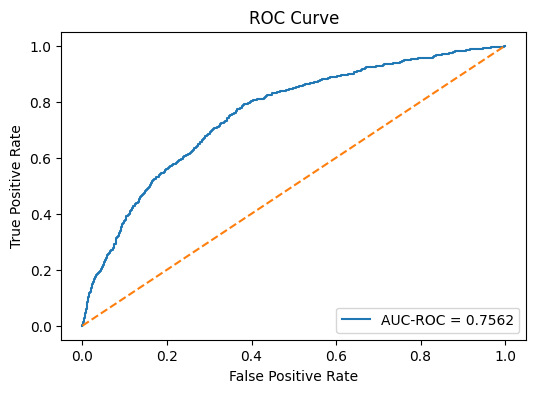

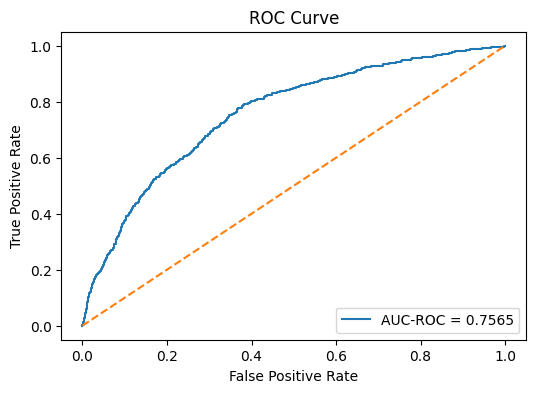

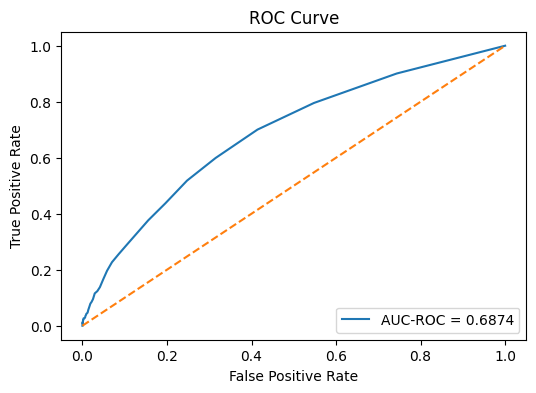

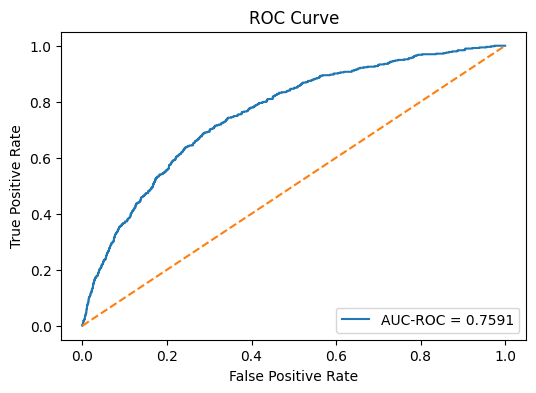

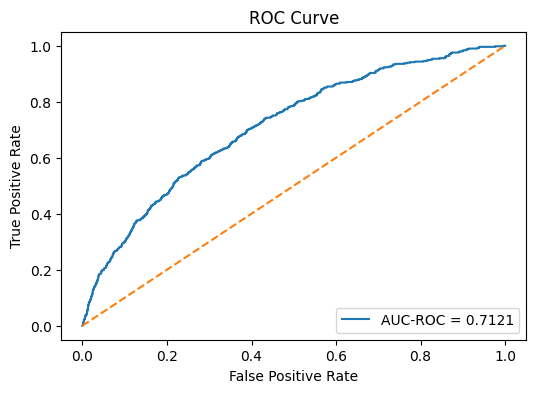

,Precision,Recall,F1 Score,AUC-ROC
L1 Logistic Regression,0.050956,0.706478,0.095057,0.756191
L2 Logistic Regression,0.050986,0.706478,0.095108,0.756527
Random Forest,0.571429,0.008097,0.015968,0.687378
Gradient Boosting,0.052961,0.702429,0.098496,0.759091
XGBoost,0.058726,0.429150,0.103314,0.712057


In [7]:
results_L1 = evaluate_model(model_L1, X_test_transformed, y_test)
results_L2 = evaluate_model(model_L2, X_test_transformed, y_test)
results_RF = evaluate_model(model_RF, X_test_transformed, y_test)
results_GB = evaluate_model(model_GB, X_test_transformed, y_test)
results_XGB = evaluate_model(model_XGB, X_test_transformed, y_test)

results_df = pd.DataFrame({
    'L1 Logistic Regression': results_L1,
    'L2 Logistic Regression': results_L2,
    'Random Forest': results_RF,
    'Gradient Boosting': results_GB,
    'XGBoost': results_XGB
}).T

results_df

* Among the evaluated models, Gradient Boosting and L2 Logistic Regression showed relatively stronger performance than the other candidates and were therefore selected for further analysis.
* L2 Logistic Regression achieved the highest recall, indicating a strong ability to identify default cases, although its precision remained very low, suggesting a large number of false positives.
* Gradient Boosting achieved a similar level of recall while producing the highest AUC-ROC and a stronger F1-score, indicating a better overall balance between minority-class detection and overall classification performance. In contrast, Random Forest showed extremely low recall despite high precision, while XGBoost achieved the highest F1-score but a substantially lower recall.
* As a result, further analysis was focused on comparing Gradient Boosting and L2 Logistic Regression in more detail.

### 5.6.3 Threshold Tuning<a id='5.6.3_Threshold_Tuning'></a>

Threshold tuning was performed for the two strongest candidate models, Gradient Boosting and L2 Logistic Regression. This step was used to explore the trade-off between precision and recall and to determine whether a threshold other than the default value of 0.5 would provide a more suitable balance for the project objective.

In [8]:
y_prob_GB = model_GB.predict_proba(X_test_transformed)[:, 1]

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
results = []

for threshold in thresholds:
    y_pred_thresh = (y_prob_GB >= threshold).astype(int)
    
    results.append({
        'Threshold': threshold,
        'Precision': precision_score(y_test, y_pred_thresh),
        'Recall': recall_score(y_test, y_pred_thresh),
        'F1 Score': f1_score(y_test, y_pred_thresh)
    })

threshold_results = pd.DataFrame(results)
threshold_results

,Threshold,Precision,Recall,F1 Score
0,0.3,0.034517,0.904858,0.066498
1,0.4,0.042261,0.809717,0.080329
2,0.5,0.052961,0.702429,0.098496
3,0.6,0.066633,0.534413,0.118492
4,0.7,0.091388,0.315789,0.141754
5,0.8,0.135279,0.103239,0.117107


In [9]:
y_prob_L2 = model_L2.predict_proba(X_test_transformed)[:, 1]

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
results_L2_threshold = []

for threshold in thresholds:
    y_pred_thresh = (y_prob_L2 >= threshold).astype(int)
    
    results_L2_threshold.append({
        'Threshold': threshold,
        'Precision': precision_score(y_test, y_pred_thresh),
        'Recall': recall_score(y_test, y_pred_thresh),
        'F1 Score': f1_score(y_test, y_pred_thresh)
    })

threshold_results_L2 = pd.DataFrame(results_L2_threshold)
threshold_results_L2

,Threshold,Precision,Recall,F1 Score
0,0.3,0.033856,0.896761,0.065248
1,0.4,0.041773,0.831984,0.079551
2,0.5,0.050986,0.706478,0.095108
3,0.6,0.063939,0.556680,0.114703
4,0.7,0.082622,0.372470,0.135244
5,0.8,0.121212,0.170040,0.141533


Lowering the threshold below 0.5 increased recall, but it also led to a substantial increase in false positive predictions. Although thresholds such as 0.4 captured more default cases, the resulting false positive rate was considered too high. Therefore, a threshold of 0.5 was retained for the final Gradient Boosting model, as it provided a more reasonable balance between identifying default cases and limiting excessive false alarms.

### 5.6.4 Model Selection<a id='5.6.4_Model_Selection'></a>

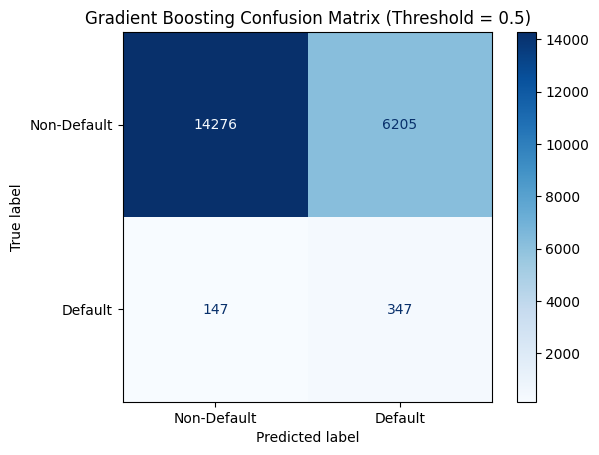

{'Precision': 0.05296092796092796,
 'Recall': 0.7024291497975709,
 'F1 Score': 0.09849560034061879,
 'AUC-ROC': 0.7590906808660619}

In [10]:
# Predicted probabilities from Gradient Boosting
y_prob_GB = model_GB.predict_proba(X_test_transformed)[:, 1]

# Apply selected threshold
threshold = 0.5
y_pred_GB_07 = (y_prob_GB >= threshold).astype(int)

# Compute confusion matrix
cm_GB_07 = confusion_matrix(y_test, y_pred_GB_07)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_GB_07,
    display_labels=['Non-Default', 'Default']
)

disp.plot(cmap='Blues', values_format='d')
plt.title('Gradient Boosting Confusion Matrix (Threshold = 0.5)')
plt.show()

results_GB

The final **Gradient Boosting** model achieved a **Recall of 0.702**, meaning it correctly identified about **70% of default cases**. Its **AUC-ROC was 0.759**, showing moderate ability to distinguish between default and non-default loans. However, **Precision was only 0.053** and the **F1-score was 0.098**, indicating that the model produced many false positive predictions. Overall, the model was relatively effective at capturing defaults, but its ability to classify defaults precisely remained limited.

## 5.7 Summary<a id='5.7_Summary'></a>

This notebook developed and evaluated several classification models for mortgage default prediction using the processed outputs from the feature engineering stage. Among the evaluated models, **Gradient Boosting** and **L2 Logistic Regression** showed relatively better performance and were selected for more detailed comparison.

After threshold tuning, **Gradient Boosting** was chosen as the final model. At the threshold of **0.5**, the model achieved a **Recall of 0.702**, indicating that it correctly identified about **70% of default cases**. The final **AUC-ROC was 0.759**, showing moderate discriminatory ability. However, **Precision remained low at 0.053**, and the confusion matrix showed a large number of false positive predictions. This suggests that the model captures some default-related patterns, but its classification precision is still limited.

Overall, the final model provides a useful starting point for mortgage default risk classification, but further improvement is needed. Future work may include additional feature engineering, hyperparameter tuning, alternative imbalance-handling approaches, and richer borrower or loan-level information to improve predictive performance.

In [11]:
final_default_model = {
    'model': model_GB,
    'transformer': transformer,
    'threshold': 0.5,
    'model_name': 'Gradient Boosting',
    'target_name': 'default',
    'feature_names': X_train.columns.tolist(),
    'metrics': {
        'precision': 0.053,
        'recall': 0.702,
        'f1_score': 0.098,
        'auc_roc': 0.759
    }
}

joblib.dump(final_default_model, '../models/final_default_model_pipeline.pkl')

print("Final default model pipeline saved successfully.")

Final default model pipeline saved successfully.
